## 🚦 Priorización de Intervenciones por Severidad de Anomalías

Este notebook genera un ranking de severidad de anomalías por pozo y etapa, utilizando los scores de modelos no supervisados.

Nos permite responder:
- ¿Qué etapas presentan más anomalías?
- ¿Dónde se concentran los scores más altos?
- ¿Qué pozos deberían priorizarse para inspección o acciones correctivas?

#### 🎯 Objetivo:

Calcular un score de severidad o “prioridad de intervención” por etapa.

Analizar:

- Cuántas anomalías hay por etapa.
- Qué tan severas son (según score máximo, media, etc.).
- Identificar las etapas más críticas.
- Visualizar todo con tablas y gráficos comparativos.


### 📂 Celda 2 – Carga de datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar dataset con anomalías
df = pd.read_csv(r"C:\Developer\fundamentos\data\ccl_anomaly_scores.csv")

# Seleccionamos score principal para el ranking
SCORE_COL = "score_iso"


### 🧮 Celda 3 – Cálculo del score de severidad por etapa

In [2]:
# Agrupar por pozo, etapa, sentido (si es relevante)
grupo = df.groupby(["pozo", "etapa"])

# Crear tabla resumen
ranking = grupo.agg(
    n_puntos=("DEPT", "count"),
    score_max=(SCORE_COL, "max"),
    score_mean=(SCORE_COL, "mean"),
    score_std=(SCORE_COL, "std"),
    n_anomalias=(SCORE_COL, lambda x: (x > x.quantile(0.85)).sum())
).reset_index()

# Crear un score combinado (puede ajustarse)
ranking["severity_score"] = (
    ranking["score_mean"] * 0.5 +
    ranking["score_max"] * 0.3 +
    ranking["n_anomalias"] / ranking["n_puntos"] * 0.2
)


### 📊 Celda 4 – Visualización del ranking

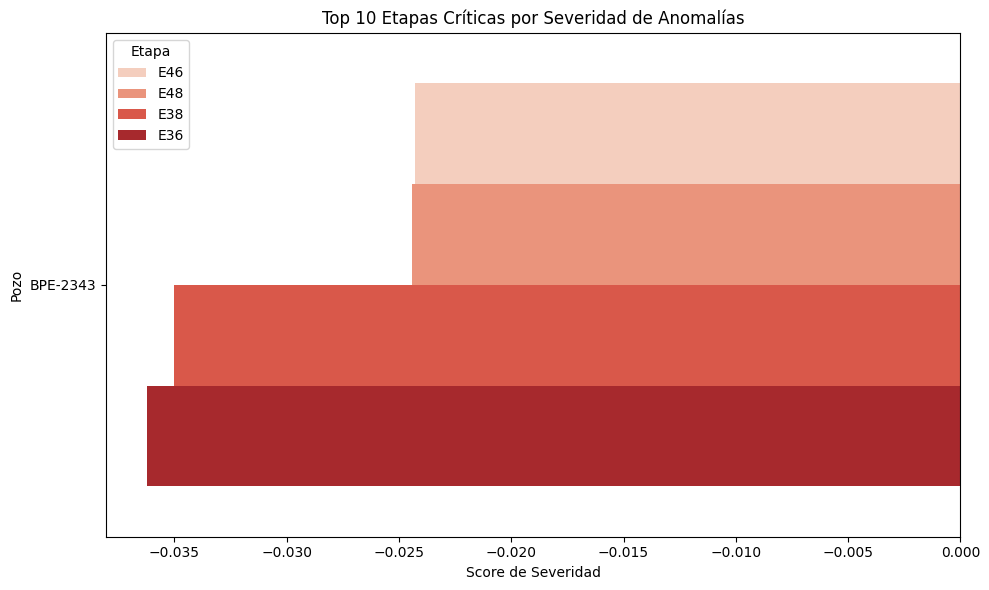

In [3]:
# Mostrar top 10 etapas críticas
top_n = 10
ranking_top = ranking.sort_values("severity_score", ascending=False).head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(data=ranking_top, x="severity_score", y="pozo", hue="etapa", palette="Reds")
plt.title(f"Top {top_n} Etapas Críticas por Severidad de Anomalías")
plt.xlabel("Score de Severidad")
plt.ylabel("Pozo")
plt.legend(title="Etapa")
plt.tight_layout()
plt.show()


### 📋 Celda 5 – Tabla completa ordenada

In [4]:
# Tabla ordenada completa
ranking.sort_values("severity_score", ascending=False).head(20)


,pozo,etapa,n_puntos,score_max,score_mean,score_std,n_anomalias,severity_score
6,BPO-2703,E16,27342,0.163064,-0.069056,0.105091,4101,0.044389
3,BPO-2703,E13,30823,0.128959,-0.157602,0.070160,4624,-0.010110
30,BPO-2703,E7,35382,0.109305,-0.194665,0.041413,5308,-0.034537
7,BPO-2703,E17,27463,0.075304,-0.177504,0.059560,4120,-0.036157
25,BPO-2703,E36,13469,0.086241,-0.186160,0.045118,2021,-0.037198
14,BPO-2703,E24,22207,0.087842,-0.189956,0.062433,3331,-0.038626
8,BPO-2703,E18,27033,0.102855,-0.206842,0.035981,4055,-0.042564
23,BPO-2703,E33,15745,0.099441,-0.206434,0.039076,2362,-0.043381
12,BPO-2703,E22,24027,0.095013,-0.205333,0.035315,3604,-0.044163
5,BPO-2703,E15,29129,0.094134,-0.211714,0.046757,4370,-0.047612


### 💾 Celda 6 – Exportación para operaciones

In [4]:
ranking.to_csv(r"C:\Developer\fundamentos\data\etapas_priorizadas.csv", index=False)
print("✅ Exportado como etapas_priorizadas.csv")


✅ Exportado como etapas_priorizadas.csv
